In [1]:
from src.dm import DataModule

dm = DataModule(batch_size=4, num_workers=0, pin_memory=False)

dm.setup()

In [2]:
dm.test_df

,image,AOD
0,data/test_images/test_1.tif,1.442470
1,data/test_images/test_2.tif,0.910374
2,data/test_images/test_3.tif,0.500745
3,data/test_images/test_4.tif,0.999882
4,data/test_images/test_5.tif,1.668206
...,...,...
1484,data/test_images/test_1485.tif,1.597977
1485,data/test_images/test_1486.tif,1.819262
1486,data/test_images/test_1487.tif,1.334963
1487,data/test_images/test_1488.tif,0.231196


In [9]:
import os

os.listdir('checkpoints')

['da-epoch=199.ckpt',
 'lrsch-val_metric=0.94095-epoch=461.ckpt',
 'da-val_metric=0.93513-epoch=486.ckpt',
 'da-epoch=99.ckpt',
 'da-epoch=405.ckpt',
 'lrsch-val_metric=0.94319-epoch=150.ckpt',
 'da-val_metric=0.94160-epoch=364.ckpt',
 'da-epoch=499.ckpt',
 'da-val_metric=0.82154-epoch=99.ckpt',
 'da-val_metric=0.91423-epoch=199.ckpt']

In [10]:
import torch 
from src.module import Module

name = "da-val_metric=0.94160-epoch=364.ckpt"
checkpoint = f'./checkpoints/{name}'


checkpoint = torch.load(checkpoint, map_location='cpu')
state_dict = checkpoint['state_dict']
module = Module()
module.load_state_dict(state_dict)

<All keys matched successfully>

In [11]:
checkpoint['hyper_parameters']

{'freeze': True,
 'optimizer': 'Adam',
 'optimizer_params': {'lr': 0.0003},
 'ckpt_path': None,
 'load_from_checkpoint': None,
 'trainer': {'accelerator': 'cuda',
  'devices': 1,
  'max_epochs': 500,
  'logger': <lightning.pytorch.loggers.wandb.WandbLogger at 0x7f8edc0aeca0>,
  'enable_checkpointing': True,
  'overfit_batches': 0,
  'precision': '16-mixed',
  'deterministic': True,
  'callbacks': [<lightning.pytorch.callbacks.model_checkpoint.ModelCheckpoint at 0x7f8edc0aed00>,
   <lightning.pytorch.callbacks.model_summary.ModelSummary at 0x7f8ef02d44f0>]},
 'datamodule': {'batch_size': 64,
  'num_workers': 20,
  'pin_memory': True,
  'train_trans': {'HorizontalFlip': {'p': 0.5},
   'VerticalFlip': {'p': 0.5},
   'Transpose': {'p': 0.5},
   'RandomRotate90': {'p': 0.5}},
  'val_size': 0.2,
  'bands': [2, 3, 4, 5, 6, 7, 8, 9, 11, 12]},
 'scheduler': 'OneCycleLR',
 'scheduler_params': {'max_lr': 0.005,
  'total_steps': 500,
  'pct_start': 0.03,
  'final_div_factor': 10,
  'verbose': True

In [12]:
class Identity:
    def __call__(self, x):
        return x

class Rot90:
    def __init__(self, axes=(2, 3)):
        self.axes = axes
    def __call__(self, x):
        return torch.rot90(x, 1, self.axes)

class Rot180:
    def __init__(self, axes=(2, 3)):
        self.axes = axes
    def __call__(self, x):
        return torch.rot90(x, 2, self.axes)

class Rot270:
    def __init__(self, axes=(2, 3)):
        self.axes = axes
    def __call__(self, x):
        return torch.rot90(x, 3, self.axes)

class Flip:
    def __init__(self, axis=2):
        self.axis = axis
    def __call__(self, x):
        return torch.flip(x, [self.axis])

class Transpose:
    def __init__(self, axes=(2, 3)):
        self.axes = axes
    def __call__(self, x):
        return torch.transpose(x, self.axes[0], self.axes[1])

trans = [
    (Identity(), Identity()),
    (Rot90(), Rot270()),
    (Rot180(), Rot180()),
    (Rot270(), Rot90()),
    (Flip(2), Flip(2)),
    (Flip(3), Flip(3)),
    (Transpose(), Transpose()),
]

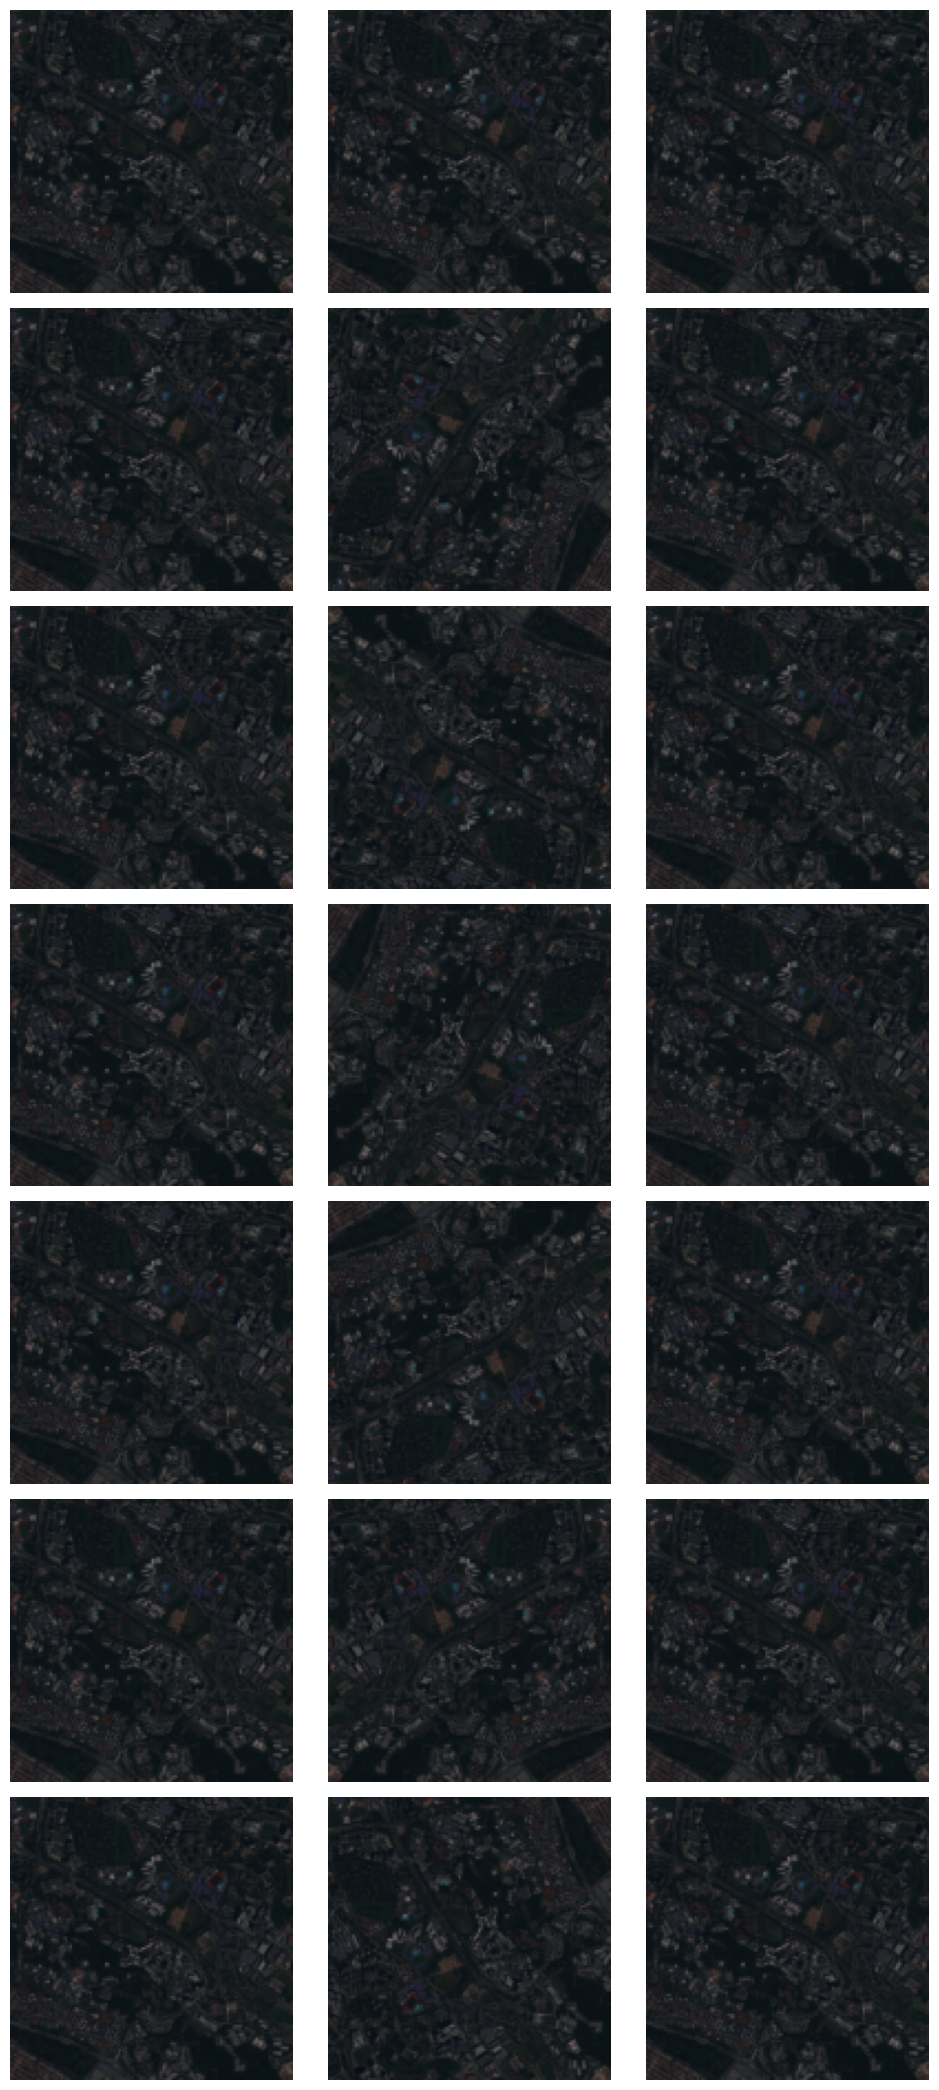

In [13]:
import torch 
import matplotlib.pyplot as plt 

dl = dm.train_dataloader(batch_size=1)
datacube, _ = next(iter(dl))

def get_image(x):
    return x[0][(2,1,0), ...].permute(1,2,0)

fig, ax = plt.subplots(len(trans), 3, figsize=(10, 3*len(trans)))
for i, (t1, t2) in enumerate(trans):
    x = datacube['pixels']
    ax[i, 0].imshow(get_image(x))
    ax[i, 0].axis('off')
    ax[i, 1].imshow(get_image(t1(x)))
    ax[i, 1].axis('off')
    ax[i, 2].imshow(get_image(t2(t1(x))))
    ax[i, 2].axis('off')
plt.tight_layout()
plt.show()

In [16]:
from tqdm import tqdm 
import torchmetrics

trans = [
    Identity(),
    Rot90(), 
    Rot180(), 
    Rot270(), 
    Flip(2), 
    Flip(3), 
    Transpose()
]

device = "cuda:1"
module.to(device)
module.eval()

dm = DataModule(batch_size=32, num_workers=8, pin_memory=True, val_size=0.2)
dm.setup()
dl = dm.val_dataloader(batch_size=4, shuffle=False)
metric = torchmetrics.PearsonCorrCoef()
pgbar = tqdm(dl, total=len(dl), leave=True)
cumulative_metric = 0.0
num_batches = 0
for batch in pgbar:
    x, y = batch
    x = {k: v.to(device) for k, v in x.items()}
    x0 = x['pixels'].clone()
    preds = []
    for t in trans:
        x['pixels'] = t(x0)
        preds.append(module(x))
    preds = torch.stack(preds).mean(0).cpu()
    metric.update(preds, y)

final_metric = metric.compute().item()
print(f"Final Metric: {final_metric:.5f}")

100%|██████████| 224/224 [00:37<00:00,  6.01it/s]

Final Metric: 0.95008


In [17]:
from tqdm import tqdm

trans = [
    Identity(),
    Rot90(), 
    Rot180(), 
    Rot270(), 
    Flip(2), 
    Flip(3), 
    Transpose()
]

device = "cuda:1"
module.to(device)
module.eval()


preds = []
for batch in tqdm(dm.test_dataloader()):
    dict_of_tensors, _ = batch
    dict_of_tensors = {k: v.to(device) for k, v in dict_of_tensors.items()}
    x0 = dict_of_tensors['pixels'].clone()
    _preds = []
    with torch.no_grad():
        for t in trans:
            dict_of_tensors['pixels'] = t(x0)
            _preds.append(module(dict_of_tensors))
    output = torch.stack(_preds).mean(0).cpu()
    output = output * dm.aod_stats[1] + dm.aod_stats[0] 
    preds += output.cpu().tolist()

  0%|          | 0/47 [00:00<?, ?it/s]

100%|██████████| 47/47 [00:34<00:00,  1.35it/s]


In [18]:
dm.test_df['AOD'] = preds
dm.test_df.image = dm.test_df.image.apply(lambda x: x.split('/')[-1])

dm.test_df

,image,AOD
0,test_1.tif,0.031499
1,test_2.tif,0.192960
2,test_3.tif,0.221083
3,test_4.tif,0.134789
4,test_5.tif,0.063134
...,...,...
1484,test_1485.tif,0.139631
1485,test_1486.tif,0.103604
1486,test_1487.tif,0.066325
1487,test_1488.tif,0.205061


In [19]:
dm.test_df.to_csv('submission.csv', index=False, header=False)